In [1]:
import xarray as xr 
import numpy as np
import matplotlib.pyplot as plt

In [61]:
# check if the daily data is nan
fn = '/pscratch/sd/l/linyaoly/ML_MJO_2024_redo/data/daily/olr.day.nc'
fn = '/pscratch/sd/l/linyaoly/ML_MJO_2024_redo/data/anomaly/olr.anomaly.1978to2025based1979to2001.nc'
fn = '/pscratch/sd/l/linyaoly/ML_MJO_2024_redo/data/fltano120/olr.fltano120.1978to2025based1979to2001.nc'
dsolr = xr.open_dataset(fn)
print(dsolr.olr.isnull().sum().values) 
print(dsolr.olr.time[0].values)
print(dsolr.olr.time[-1].values)
fn = '/pscratch/sd/l/linyaoly/ML_MJO_2024_redo/data/daily/u200.day.nc'
fn = '/pscratch/sd/l/linyaoly/ML_MJO_2024_redo/data/anomaly/u200.anomaly.1978to2025based1979to2001.nc'
fn = '/pscratch/sd/l/linyaoly/ML_MJO_2024_redo/data/fltano120/u200.fltano120.1978to2025based1979to2001.nc'
dsu200 = xr.open_dataset(fn)
print(dsu200.u200.isnull().sum().values) 
print(dsu200.u200.time[0].values)
print(dsu200.u200.time[-1].values)
fn = '/pscratch/sd/l/linyaoly/ML_MJO_2024_redo/data/daily/u850.day.nc'
fn = '/pscratch/sd/l/linyaoly/ML_MJO_2024_redo/data/anomaly/u850.anomaly.1978to2025based1979to2001.nc'
fn = '/pscratch/sd/l/linyaoly/ML_MJO_2024_redo/data/fltano120/u850.fltano120.1978to2025based1979to2001.nc'
dsu850 = xr.open_dataset(fn)
print(dsu850.u850.isnull().sum().values) 
print(dsu850.u850.time[0].values)
print(dsu850.u850.time[-1].values)

0
1979-01-01T00:00:00.000000000
2025-02-14T00:00:00.000000000
0
1979-01-01T00:00:00.000000000
2025-02-14T00:00:00.000000000
0
1979-01-01T00:00:00.000000000
2025-02-14T00:00:00.000000000


In [60]:
fn = '/pscratch/sd/l/linyaoly/ML_MJO_2024_redo/data/anomaly/sst.anomaly.1978to2025based1979to2001.nc'
dsu850 = xr.open_dataset(fn)
print(dsu850.sst.isnull().sum().values) 
print(dsu850.sst.time[0].values)
print(dsu850.sst.time[-1].values)

0
1978-01-01T00:00:00.000000000
2025-02-14T00:00:00.000000000


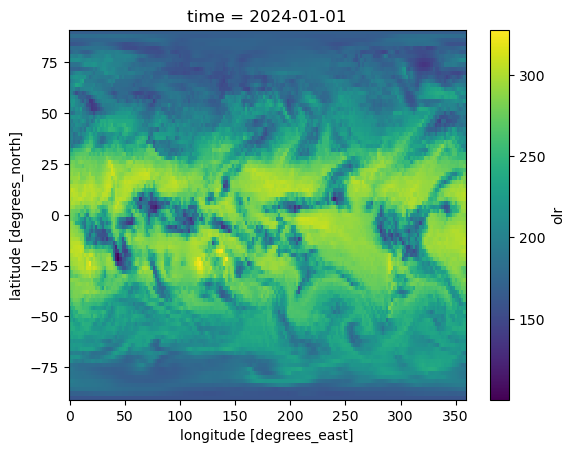

In [9]:
dsolr.sel(time='2024-01-01').olr.plot()

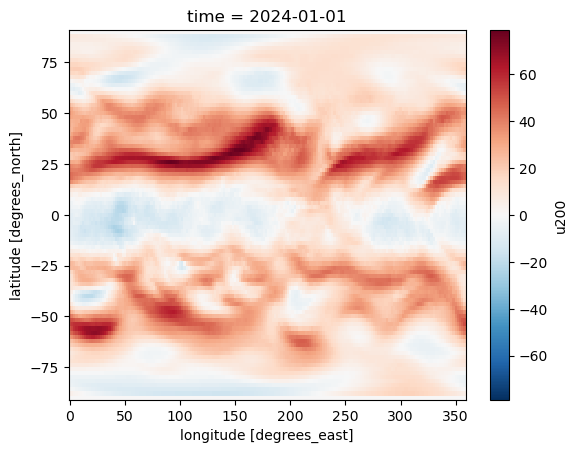

In [10]:
dsu200.sel(time='2024-01-01').u200.plot()

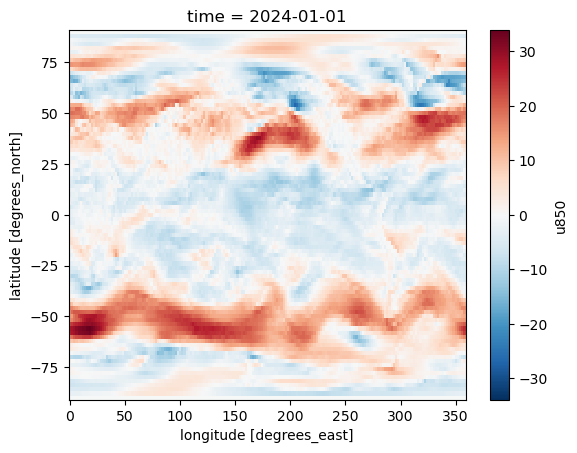

In [11]:
dsu850.sel(time='2024-01-01').u850.plot()

shape of raw climatological maps:  (366, 91, 1)


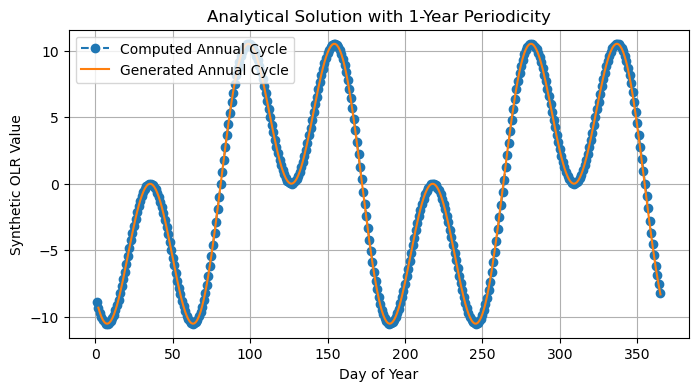

In [28]:
# check if the anomaly is correct. 
def get_raw_clim_annual_cycle(x, latsel=90, year_sta=1979, year_end=2001):
    # x is a variable 
    # x[time, lat, lon]
    if latsel == 90:
        x_sel = x.sel(time=slice(str(year_sta)+'-01-01', str(year_end)+'-12-31')).fillna(0)
    else:
        x_sel = x.sel(time=slice(str(year_sta)+'-01-01', str(year_end)+'-12-31'), lat=slice(latsel,-latsel)).fillna(0)
    
    # x_sel = x_sel.sel(time=~((x_sel.time.dt.month == 2) & (x_sel.time.dt.day == 29)))

    x_sel_clim = x_sel.groupby("time.dayofyear").mean()

    x_values = x_sel_clim.values

    print('shape of raw climatological maps: ', x_values.shape)

    x_values[-1,:,:] = 0.5 * (x_values[-2,:,:] + x_values[0,:,:])

    return x_sel_clim, x_values

import pandas as pd

def generate_analytical_solution(years=30, lat_range=(90, -90), lon_range=(0, 360), res=2):
    """
    Generates an analytical solution with a frequency of 1/year,
    correctly handling both leap and non-leap years.
    """

    # Time range: daily values over 'years' years
    start_year = 1979
    time = pd.date_range(start=f'{start_year}-01-01', periods=years * 365, freq='D')

    # Adjust for leap years (add Feb 29 where applicable)
    time = time[~((time.month == 2) & (time.day == 29))]  # Remove Feb 29 to keep DOY aligned

    nt = len(time)

    # Spatial range: 2° x 2° lat-lon grid
    lat = np.arange(lat_range[0], lat_range[1] - res, -res)
    lon = np.arange(lon_range[0], lon_range[1], res)

    # Compute normalized time variable: fraction of the year completed
    days_in_year = np.array([366 if (pd.Timestamp(t).year % 4 == 0 and (pd.Timestamp(t).year % 100 != 0 or pd.Timestamp(t).year % 400 == 0)) else 365 for t in time])
    doy = np.array([t.dayofyear for t in time])
    t_norm = (doy - 1) / days_in_year  # Normalized DOY

    # Generate synthetic OLR data: 1/year sinusoidal function
    omega1 = 2 * np.pi * 2  
    omega2 = 2 * np.pi * 6# One cycle per year
    amplitude = 20  # Arbitrary amplitude
    phase_shift = 80 / 365  # Adjusted for one-year period
    spatial_variability = np.cos(np.radians(lat))[:, None]  # Varies with latitude

    olr_values = amplitude * (np.sin(omega1 * (t_norm - phase_shift))[:, None, None] + np.sin(omega2 * (t_norm - phase_shift))[:, None, None] ) * spatial_variability

    # Convert to xarray DataArray
    ds = xr.DataArray(
        olr_values,
        coords={"time": time, "lat": lat, "lon": [0]},
        dims=["time", "lat", "lon"],
        name="synthetic_olr"
    )

    return ds

# Generate test data
test_data = generate_analytical_solution()

# Apply the function to get the climatological cycle
clim_annual_cycle, clim_values = get_raw_clim_annual_cycle(test_data, latsel=90, year_sta=1979, year_end=2008)

# Plot example lat/lon
lat_idx = 10  # Select latitude index
lon_idx = 0   # Select longitude index

plt.figure(figsize=(8, 4))
plt.plot(np.arange(1, 366), clim_values[:365, lat_idx, lon_idx], label="Computed Annual Cycle", linestyle="--", marker="o")
plt.plot(test_data[1:365, lat_idx, lon_idx].time.dt.dayofyear, test_data[1:365, lat_idx, lon_idx], label="Generated Annual Cycle", linestyle="-")
plt.xlabel("Day of Year")
plt.ylabel("Synthetic OLR Value")
plt.title("Analytical Solution with 1-Year Periodicity")
plt.legend()
plt.grid()
plt.show()

In [29]:
from util.MJO_indices_util import * 
smclimvalues = get_smoothed_clim_annual_cycle(clim_values)

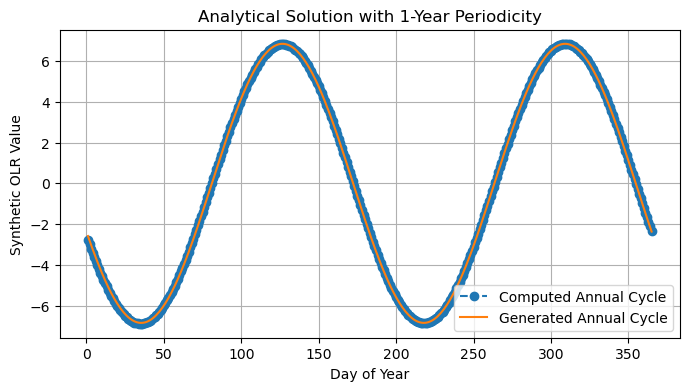

In [35]:
plt.figure(figsize=(8, 4))
plt.plot(np.arange(1, 366), smclimvalues[:365, lat_idx, lon_idx], label="Computed Annual Cycle", linestyle="--", marker="o")
plt.plot(np.arange(1, 366), amplitude * (np.sin(2 * np.pi * 2 * (np.arange(0,365)/365 - phase_shift))) * np.cos(np.radians(lat[lat_idx])), label="Generated Annual Cycle", linestyle="-")
plt.xlabel("Day of Year")
plt.ylabel("Synthetic OLR Value")
plt.title("Analytical Solution with 1-Year Periodicity")
plt.legend()
plt.grid()
plt.show()

In [57]:
clim_annual_cycle.values = smclimvalues
# Compute anomalies directly
test_ano = test_data.groupby("time.dayofyear") - clim_annual_cycle


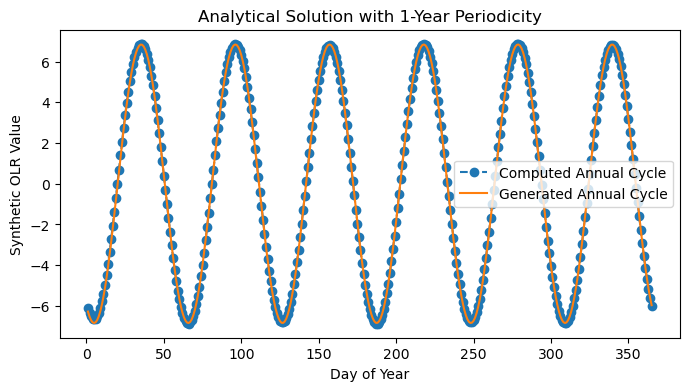

In [58]:

plt.figure(figsize=(8, 4))
plt.plot(np.arange(1, 366), test_ano[:365, lat_idx, lon_idx], label="Computed Annual Cycle", linestyle="--", marker="o")
plt.plot(np.arange(1, 366), amplitude * (np.sin(2 * np.pi * 6 * (np.arange(0,365)/365 - phase_shift)) * np.cos(np.radians(lat[lat_idx]))), label="Generated Annual Cycle", linestyle="-")
plt.xlabel("Day of Year")
plt.ylabel("Synthetic OLR Value")
plt.title("Analytical Solution with 1-Year Periodicity")
plt.legend()